In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE


df = pd.read_csv("D:/Đại học/1. Nghiên cứu Khoa học/Dataset/Folder_Dataset/P2P_Dataset.csv")
boolean_cols = df.select_dtypes(include=['bool']).columns
df[boolean_cols] = df[boolean_cols].astype(int)


In [ ]:
df = df.drop(columns=["badloan", "funded_amnt", "sub_grade", "pub_rec", "num_tl_30dpd"])

Biến: acc_now_delinq, Tầm quan trọng: 0.00010
Biến: acc_open_past_24mths, Tầm quan trọng: 0.01236
Biến: annual_inc, Tầm quan trọng: 0.02292
Biến: chargeoff_within_12_mths, Tầm quan trọng: 0.00042
Biến: collections_12_mths_ex_med, Tầm quan trọng: 0.00091
Biến: delinq_2yrs, Tầm quan trọng: 0.00274
Biến: delinq_amnt, Tầm quan trọng: 0.00037
Biến: dti, Tầm quan trọng: 0.02613
Biến: earnings, Tầm quan trọng: 0.03049
Biến: emp_length, Tầm quan trọng: 0.08268
Biến: grade, Tầm quan trọng: 0.00622
Biến: inq_last_12m, Tầm quan trọng: 0.18839
Biến: inq_last_6mths, Tầm quan trọng: 0.00565
Biến: installment, Tầm quan trọng: 0.01874
Biến: int_rate, Tầm quan trọng: 0.13198
Biến: loan_amnt, Tầm quan trọng: 0.01249
Biến: loan_vol6m, Tầm quan trọng: 0.02895
Biến: mort_acc, Tầm quan trọng: 0.00735
Biến: mths_since_last_delinq, Tầm quan trọng: 0.01344
Biến: num_accts_ever_120_pd, Tầm quan trọng: 0.00371
Biến: num_actv_rev_tl, Tầm quan trọng: 0.01209
Biến: open_acc, Tầm quan trọng: 0.01453
Biến: pct_tl_nvr

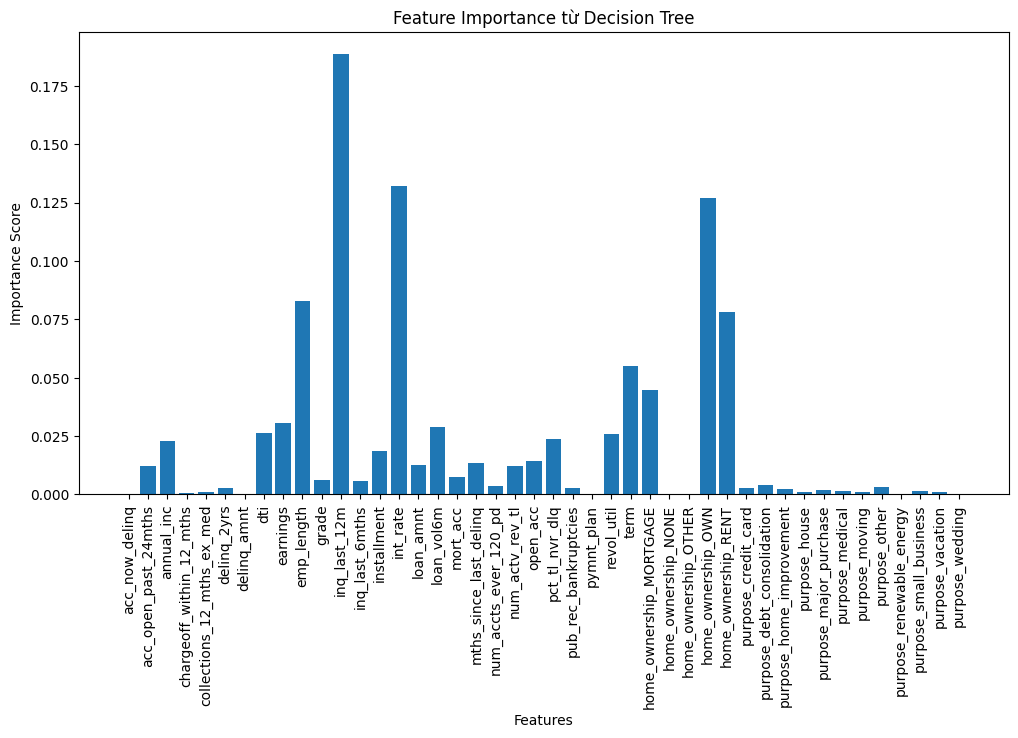

In [ ]:
# 🎯 Chia X, y
X = df.drop(columns=["default_binary"], errors="ignore")
y = df["default_binary"]

# 🔀 Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

# ⚖️ Cân bằng dữ liệu bằng SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 🚀 Huấn luyện Decision Tree trên dữ liệu đã cân bằng
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

# 🔍 Lấy độ quan trọng của từng biến
importance_dt = dt_model.feature_importances_

# 📊 Hiển thị tầm quan trọng của biến
for i, v in enumerate(importance_dt):
    print(f'Biến: {X_train.columns[i]}, Tầm quan trọng: {v:.5f}')

# 🎨 Vẽ biểu đồ Feature Importance
plt.figure(figsize=(12, 6))
plt.bar([x for x in range(len(importance_dt))], importance_dt)
plt.xticks(range(len(importance_dt)), X_train.columns, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance từ Decision Tree")
plt.show()


In [ ]:
# 🎯 Chỉ chọn các biến có tầm quan trọng > 0.01
important_features_dt = X_train.columns[importance_dt > 0.01]

# 🔄 Cập nhật X_train và X_test chỉ với các biến quan trọng
X_train_selected = X_train_resampled[important_features_dt]
X_test_selected = X_test[important_features_dt]

# 🔄 Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)


In [ ]:
# 📌 Định nghĩa không gian tham số
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight': [None, 'balanced']
}

# 🚀 Grid Search tìm tham số tối ưu
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_selected_scaled, y_train_resampled)

# 🔥 Kết quả siêu tham số tối ưu
print("\n🔥 Best Hyperparameters for Decision Tree:")
print(grid_search.best_params_)



🔥 Best Hyperparameters for Decision Tree:
{'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 20}


In [ ]:
# 🚀 Huấn luyện mô hình với tham số tối ưu
best_dt = grid_search.best_estimator_
best_dt.fit(X_train_selected_scaled, y_train_resampled)

# 📊 Dự đoán trên tập kiểm tra
y_pred = best_dt.predict(X_test_selected_scaled)
y_prob = best_dt.predict_proba(X_test_selected_scaled)[:, 1]

# 🎯 Tính các chỉ số đánh giá
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# 📊 In kết quả
print("\n📊 Decision Tree Model Evaluation")
print(f"🎯 Accuracy: {accuracy:.4f}")
print(f"🚀 AUC-ROC: {roc_auc:.4f}")
print(f"📑 Classification Report:\n{report}")
print(f"📊 Confusion Matrix:\n{conf_matrix}")


📊 Decision Tree Model Evaluation
🎯 Accuracy: 0.9039
🚀 AUC-ROC: 0.7019
📑 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95    494039
           1       0.26      0.06      0.10     46647

    accuracy                           0.90    540686
   macro avg       0.59      0.52      0.52    540686
weighted avg       0.86      0.90      0.88    540686

📊 Confusion Matrix:
[[485995   8044]
 [ 43890   2757]]
